# AXIS 2: Topic Modeling Comparison



# 1) Setup & Installation

In [1]:

%pip install bertopic gensim scikit-learn matplotlib seaborn pandas numpy scipy --break-system-packages -q

Note: you may need to restart the kernel to use updated packages.


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import load_npz
import pickle
import os
from collections import Counter
from sklearn.decomposition import LatentDirichletAllocation
from bertopic import BERTopic
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
from sklearn.cluster import KMeans



# 2) Load Data from AXIS 1

In [3]:

df = pd.read_csv('../complete_preprocessing_final.csv')
texts = df['trunc_processed_text'].values
true_labels = df['type'].values

print(f"Loaded {len(texts):,} documents")
print(f"Ground truth: {df['type'].value_counts().to_dict()}")

Loaded 27,919 documents
Ground truth: {'Incident': 11093, 'Request': 8030, 'Problem': 5832, 'Change': 2964}


# 3) Load TF-IDF from AXIS 1

In [4]:

X_tfidf = load_npz('tfidfvectors.npz')

with open('tfidfvectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

feature_names = vectorizer.get_feature_names_out()
print(f"TF IDF shape: {X_tfidf.shape}")
print(f"Vocabulary: {len(feature_names):,} words")

TF IDF shape: (27919, 5000)
Vocabulary: 5,000 words


# 4) Load embeddings from AXIS 1

In [5]:

X_emb = np.load('embeddings.npy')
print(f"Embeddings shape: {X_emb.shape}")

Embeddings shape: (27919, 384)


# 5) Recreate AXIS 1 clusters for comparison

In [6]:

km_axis1 = KMeans(n_clusters=5, random_state=42, n_init=10)
axis1_clusters = km_axis1.fit_predict(X_emb)
print(f"AXIS 1 clusters: {np.bincount(axis1_clusters)}")

AXIS 1 clusters: [ 3910  5987  3992 10174  3856]


# 6) Configuration

In [7]:
N_TOPICS = 5
RANDOM_STATE = 42
print(f"Topics: {N_TOPICS}, Seed: {RANDOM_STATE}")

Topics: 5, Seed: 42


# 7) Method 1: LDA (Latent Dirichlet Allocation)

In [8]:

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=RANDOM_STATE,
    max_iter=20,
    learning_method='online',
    n_jobs=-1
)

lda_topic_distributions = lda.fit_transform(X_tfidf)
lda_topics = lda_topic_distributions.argmax(axis=1)
print(f"Perplexity: {lda.perplexity(X_tfidf):.2f}")
print(f"Distribution: {np.bincount(lda_topics)}")

Perplexity: 2390.81
Distribution: [2863 4207 4038 7305 9506]


# 8) Extract LDA topics

In [9]:

def get_top_words_lda(model, feature_names, n_words=10):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        top_scores = [topic[i] for i in top_indices]
        topics[topic_idx] = list(zip(top_words, top_scores))
    return topics

lda_topics_words = get_top_words_lda(lda, feature_names, n_words=10)

print("\nLDA Topics:")
for idx, words in lda_topics_words.items():
    word_list = [w for w, s in words]
    print(f"Topic {idx}: {', '.join(word_list)}")


LDA Topics:
Topic 0: issue, additional, matter, bill, let, let know, look, additional information, know, contact
Topic 1: security, medical, medical data, access, data, breach, hospital, system, measure, patient
Topic 2: digital, brand, strategy, market, growth, digital strategy, brand growth, campaign, engagement, digital market
Topic 3: detail, provide, integration, information, tool, management, investment, integrate, data, project
Topic 4: issue, problem, restart, resolve, software, update, server, encounter, recent, face


# 9) Method 2: BERTopic (with Empty Topic Fix)

In [10]:

bertopic_model = BERTopic(
    verbose=False,
    min_topic_size=100,
    calculate_probabilities=False
)

initial_topics, _ = bertopic_model.fit_transform(texts, X_emb)
bertopic_model.reduce_topics(texts, nr_topics=N_TOPICS)
bert_topics = np.array(bertopic_model.topics_, dtype=int)


if -1 in bert_topics:
    n_outliers = (bert_topics == -1).sum()
    bert_topics[bert_topics == -1] = 0
    print(f"Mapped {n_outliers} outliers to topic 0")


unique_topics = np.unique(bert_topics)
topic_mapping = {old: new for new, old in enumerate(unique_topics)}
bert_topics = np.array([topic_mapping[t] for t in bert_topics])


print(f"Topics: {np.unique(bert_topics)}")
print(f"Distribution: {np.bincount(bert_topics)}")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Mapped 1524 outliers to topic 0
Topics: [0 1 2 3]
Distribution: [12773  6390  5047  3709]


# 10) Extract BERTopic topics WITH FALLBACK

In [11]:



bert_topics_words = {}

for topic_id in range(N_TOPICS):
    topic_words = bertopic_model.get_topic(topic_id)
    
    if topic_words and len(topic_words) > 0:
        bert_topics_words[topic_id] = topic_words[:10]
        print(f"✓ Topic {topic_id}: {len(topic_words)} words")
    else:
       
        print(f"Topic {topic_id}: Empty")
        topic_docs_mask = bert_topics == topic_id
        
        if topic_docs_mask.sum() > 0:
            topic_texts = [texts[i] for i in np.where(topic_docs_mask)[0][:1000]]
            word_freq = Counter()
            for text in topic_texts:
                word_freq.update(text.split())
            
            top_words = word_freq.most_common(10)
            bert_topics_words[topic_id] = [(w, float(c)/sum(word_freq.values())) for w, c in top_words]
            print(f"  Created fallback with {len(top_words)} words")
        else:
            bert_topics_words[topic_id] = [("placeholder", 0.0)] * 10

print("\nBERTopic Topics:")
for idx, words in bert_topics_words.items():
    if words:
        word_list = [w for w, s in words]
        print(f"Topic {idx}: {', '.join(word_list)}")

✓ Topic 0: 10 words
✓ Topic 1: 10 words
✓ Topic 2: 10 words
✓ Topic 3: 10 words
Topic 4: Empty

BERTopic Topics:
Topic 0: issue, problem, resolve, restart, update, software, data, recent, server, matter
Topic 1: security, medical, data, access, breach, hospital, information, system, patient, measure
Topic 2: investment, tool, integration, provide, analytics, project, detail, management, data, appreciate
Topic 3: digital, brand, strategy, market, growth, engagement, campaign, target, enhance, content
Topic 4: placeholder, placeholder, placeholder, placeholder, placeholder, placeholder, placeholder, placeholder, placeholder, placeholder


#  11) Evaluation Metrics

In [12]:

tokenized_texts = [text.split() for text in texts]
dictionary = Dictionary(tokenized_texts)
print(f"Dictionary: {len(dictionary)} tokens")

Dictionary: 3670 tokens


# 12) Coherence calculation

In [13]:
 
def calculate_coherence(topics_dict, texts, dictionary):
    topics_list = []
    
    for topic_id in sorted(topics_dict.keys()):
        if not topics_dict[topic_id] or len(topics_dict[topic_id]) == 0:
            print(f"  Skipping empty topic {topic_id}")
            continue
        
       
        words = []
        for item in topics_dict[topic_id]:
            if isinstance(item, tuple) and len(item) >= 2:
                word = str(item[0]).strip()
                if word and word != 'placeholder':
                    words.append(word)
            elif isinstance(item, str):
                word = str(item).strip()
                if word and word != 'placeholder':
                    words.append(word)
        
     
        if words and len(words) > 0:
            topics_list.append(words)
            print(f"  Topic {topic_id}: {len(words)} words - {words[:3]}...")
        else:
            print(f"  Topic {topic_id}: No valid words after extraction")
    
    if not topics_list or len(topics_list) == 0:
        print("  No valid topics found")
        return 0.0
    
    
    try:
        cm = CoherenceModel(
            topics=topics_list,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        coherence = cm.get_coherence()
        print(f"Coherence calculated: {coherence:.4f}")
        return coherence
    except Exception as e:
        print(f"  ERROR in coherence calculation: {e}")
        return 0.0

lda_coherence = calculate_coherence(lda_topics_words, tokenized_texts, dictionary)

bert_coherence = calculate_coherence(bert_topics_words, tokenized_texts, dictionary)


print("COHERENCE RESULTS")
print(f"  LDA:      {lda_coherence:.4f}")
print(f"  BERTopic: {bert_coherence:.4f}")
if lda_coherence > 0 and bert_coherence > 0:
    print(f"  Winner:   {'BERTopic' if bert_coherence > lda_coherence else 'LDA'}")
    print(f"  Diff:     {abs(bert_coherence - lda_coherence):.4f}")

  Topic 0: 10 words - ['issue', 'additional', 'matter']...
  Topic 1: 10 words - ['security', 'medical', 'medical data']...
  Topic 2: 10 words - ['digital', 'brand', 'strategy']...
  Topic 3: 10 words - ['detail', 'provide', 'integration']...
  Topic 4: 10 words - ['issue', 'problem', 'restart']...
Coherence calculated: 0.7799
  Topic 0: 10 words - ['issue', 'problem', 'resolve']...
  Topic 1: 10 words - ['security', 'medical', 'data']...
  Topic 2: 10 words - ['investment', 'tool', 'integration']...
  Topic 3: 10 words - ['digital', 'brand', 'strategy']...
  Topic 4: No valid words after extraction
Coherence calculated: 0.7617
COHERENCE RESULTS
  LDA:      0.7799
  BERTopic: 0.7617
  Winner:   LDA
  Diff:     0.0182


In [14]:
# Diversity
def calculate_diversity(topics_dict, top_n=25):
    all_words = []
    for topic_id in topics_dict:
        if isinstance(topics_dict[topic_id][0], tuple):
            words = [w for w, s in topics_dict[topic_id][:top_n]]
        else:
            words = [w for w, s in topics_dict[topic_id][:top_n]]
        all_words.extend(words)
    
    return len(set(all_words)) / len(all_words) if all_words else 0

lda_diversity = calculate_diversity(lda_topics_words)
bert_diversity = calculate_diversity(bert_topics_words)

print(f"\nDiversity:")
print(f"  LDA:      {lda_diversity:.4f}")
print(f"  BERTopic: {bert_diversity:.4f}")


Diversity:
  LDA:      0.9600
  BERTopic: 0.7800


In [15]:
# Alignment with AXIS 1
lda_ari = adjusted_rand_score(axis1_clusters, lda_topics)
bert_ari = adjusted_rand_score(axis1_clusters, bert_topics)

lda_nmi = normalized_mutual_info_score(axis1_clusters, lda_topics)
bert_nmi = normalized_mutual_info_score(axis1_clusters, bert_topics)

print(f"\nAlignment with AXIS 1:")
print(f"  ARI:  LDA={lda_ari:.4f}, BERTopic={bert_ari:.4f}")
print(f"  NMI:  LDA={lda_nmi:.4f}, BERTopic={bert_nmi:.4f}")


Alignment with AXIS 1:
  ARI:  LDA=0.5129, BERTopic=0.6307
  NMI:  LDA=0.5437, BERTopic=0.6506


# 13) LDA Model Selection (Coherence vs K)

In [16]:


k_values = [3, 5, 7, 10, 15]
lda_coherence_scores = []
lda_perplexity_scores = []

for k in k_values:
    lda_temp = LatentDirichletAllocation(
        n_components=k,
        random_state=RANDOM_STATE,
        max_iter=20,
        learning_method='online',
        n_jobs=-1
    )
    lda_temp.fit(X_tfidf)
    
    
    topics_dict = {}
    for topic_idx in range(k):
        top_indices = lda_temp.components_[topic_idx].argsort()[-10:][::-1]
        topics_dict[topic_idx] = [(feature_names[i], lda_temp.components_[topic_idx][i]) 
                                   for i in top_indices]
    
    coherence = calculate_coherence(topics_dict, tokenized_texts, dictionary)
    perplexity = lda_temp.perplexity(X_tfidf)
    
    lda_coherence_scores.append(coherence)
    lda_perplexity_scores.append(perplexity)
    
    print(f"k={k}: Coherence={coherence:.4f}, Perplexity={perplexity:.2f}")



  Topic 0: 10 words - ['digital', 'market', 'brand']...
  Topic 1: 10 words - ['issue', 'problem', 'update']...
  Topic 2: 10 words - ['information', 'data', 'detail']...
Coherence calculated: 0.7526
k=3: Coherence=0.7526, Perplexity=2388.17
  Topic 0: 10 words - ['issue', 'additional', 'matter']...
  Topic 1: 10 words - ['security', 'medical', 'medical data']...
  Topic 2: 10 words - ['digital', 'brand', 'strategy']...
  Topic 3: 10 words - ['detail', 'provide', 'integration']...
  Topic 4: 10 words - ['issue', 'problem', 'restart']...
Coherence calculated: 0.7799
k=5: Coherence=0.7799, Perplexity=2390.81
  Topic 0: 10 words - ['sap', 'erp', 'sap erp']...
  Topic 1: 10 words - ['bill', 'payment', 'subscription']...
  Topic 2: 10 words - ['schedule', 'discus', 'pro']...
  Topic 3: 10 words - ['detail', 'provide', 'tool']...
  Topic 4: 10 words - ['digital', 'brand', 'strategy']...
  Topic 5: 10 words - ['medical', 'security', 'medical data']...
  Topic 6: 10 words - ['issue', 'problem'

# 14) Visualizations

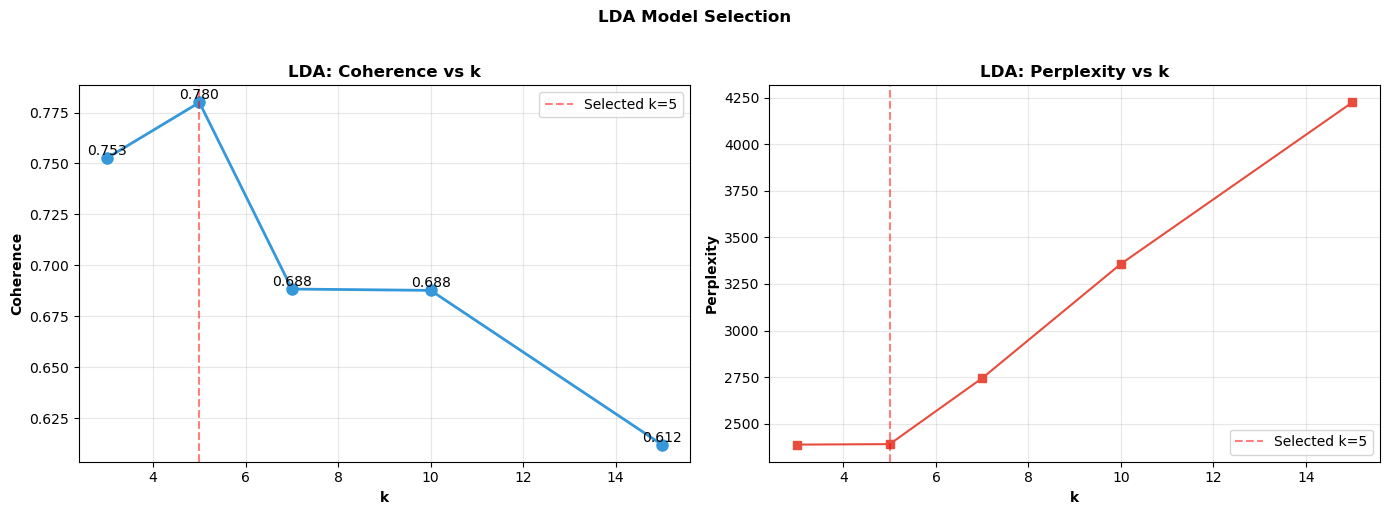

In [17]:
# 1. LDA Coherence vs K Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, lda_coherence_scores, marker='o', linewidth=2, markersize=8, color='#3498db')
axes[0].axvline(x=5, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Selected k=5')
axes[0].set_xlabel('k', fontweight='bold')
axes[0].set_ylabel('Coherence', fontweight='bold')
axes[0].set_title('LDA: Coherence vs k', fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].legend()

for k, score in zip(k_values, lda_coherence_scores):
    axes[0].text(k, score, f'{score:.3f}', ha='center', va='bottom')

axes[1].plot(k_values, lda_perplexity_scores, marker='s',color='#e74c3c')
axes[1].axvline(x=5, color='red', linestyle='--', alpha=0.5, label='Selected k=5')
axes[1].set_xlabel('k', fontweight='bold')
axes[1].set_ylabel('Perplexity', fontweight='bold')
axes[1].set_title('LDA: Perplexity vs k', fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.suptitle('LDA Model Selection', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../Outputs/axis2_lda_model_selection.png')
plt.show()


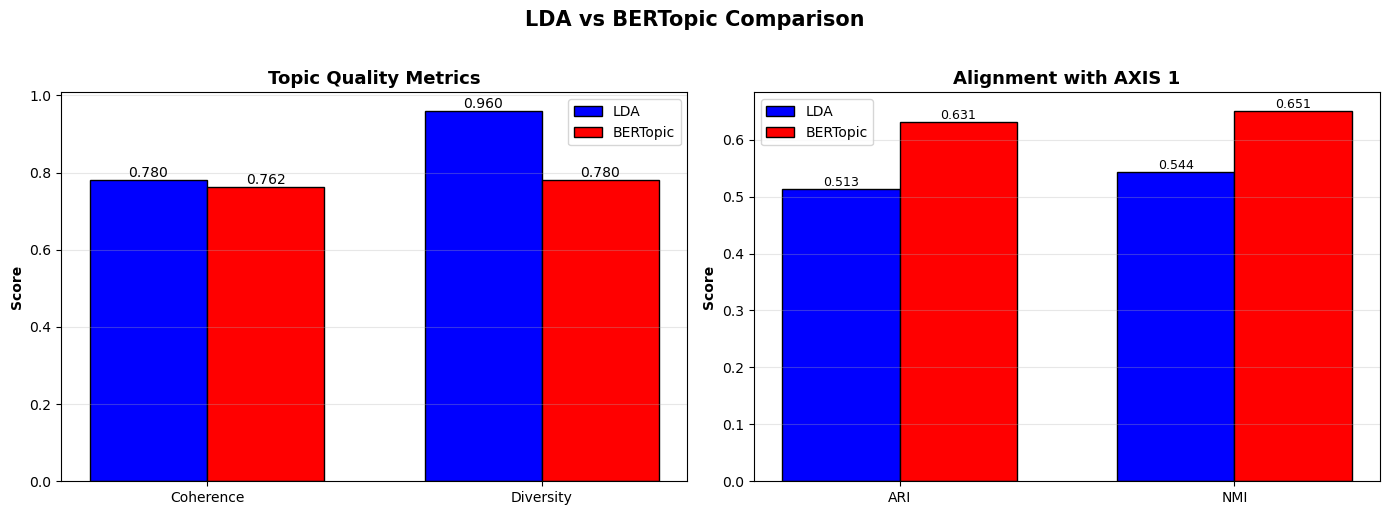

In [18]:
# 2. Metric Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Coherence', 'Diversity']
lda_scores = [lda_coherence, lda_diversity]
bert_scores = [bert_coherence, bert_diversity]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, lda_scores, width, label='LDA', color='blue', edgecolor='black')
axes[0].bar(x + width/2, bert_scores, width, label='BERTopic', color='red', edgecolor='black')
axes[0].set_ylabel('Score', fontweight='bold')
axes[0].set_title('Topic Quality Metrics', fontweight='bold', fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

for i, (lda_val, bert_val) in enumerate(zip(lda_scores, bert_scores)):
    axes[0].text(i - width/2, lda_val, f'{lda_val:.3f}', ha='center', va='bottom')
    axes[0].text(i + width/2, bert_val, f'{bert_val:.3f}', ha='center', va='bottom')

metrics2 = ['ARI', 'NMI']
lda_align = [lda_ari, lda_nmi]
bert_align = [bert_ari, bert_nmi]

x2 = np.arange(len(metrics2))

axes[1].bar(x2 - width/2, lda_align, width, label='LDA', color='blue', edgecolor='black')
axes[1].bar(x2 + width/2, bert_align, width, label='BERTopic', color='red', edgecolor='black')
axes[1].set_ylabel('Score', fontweight='bold')
axes[1].set_title('Alignment with AXIS 1', fontweight='bold', fontsize=13)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(metrics2)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

for i, (lda_val, bert_val) in enumerate(zip(lda_align, bert_align)):
    axes[1].text(i - width/2, lda_val, f'{lda_val:.3f}', ha='center', va='bottom', fontsize=9)
    axes[1].text(i + width/2, bert_val, f'{bert_val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('LDA vs BERTopic Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../Outputs/axis2_metrics_comparison.png')
plt.show()



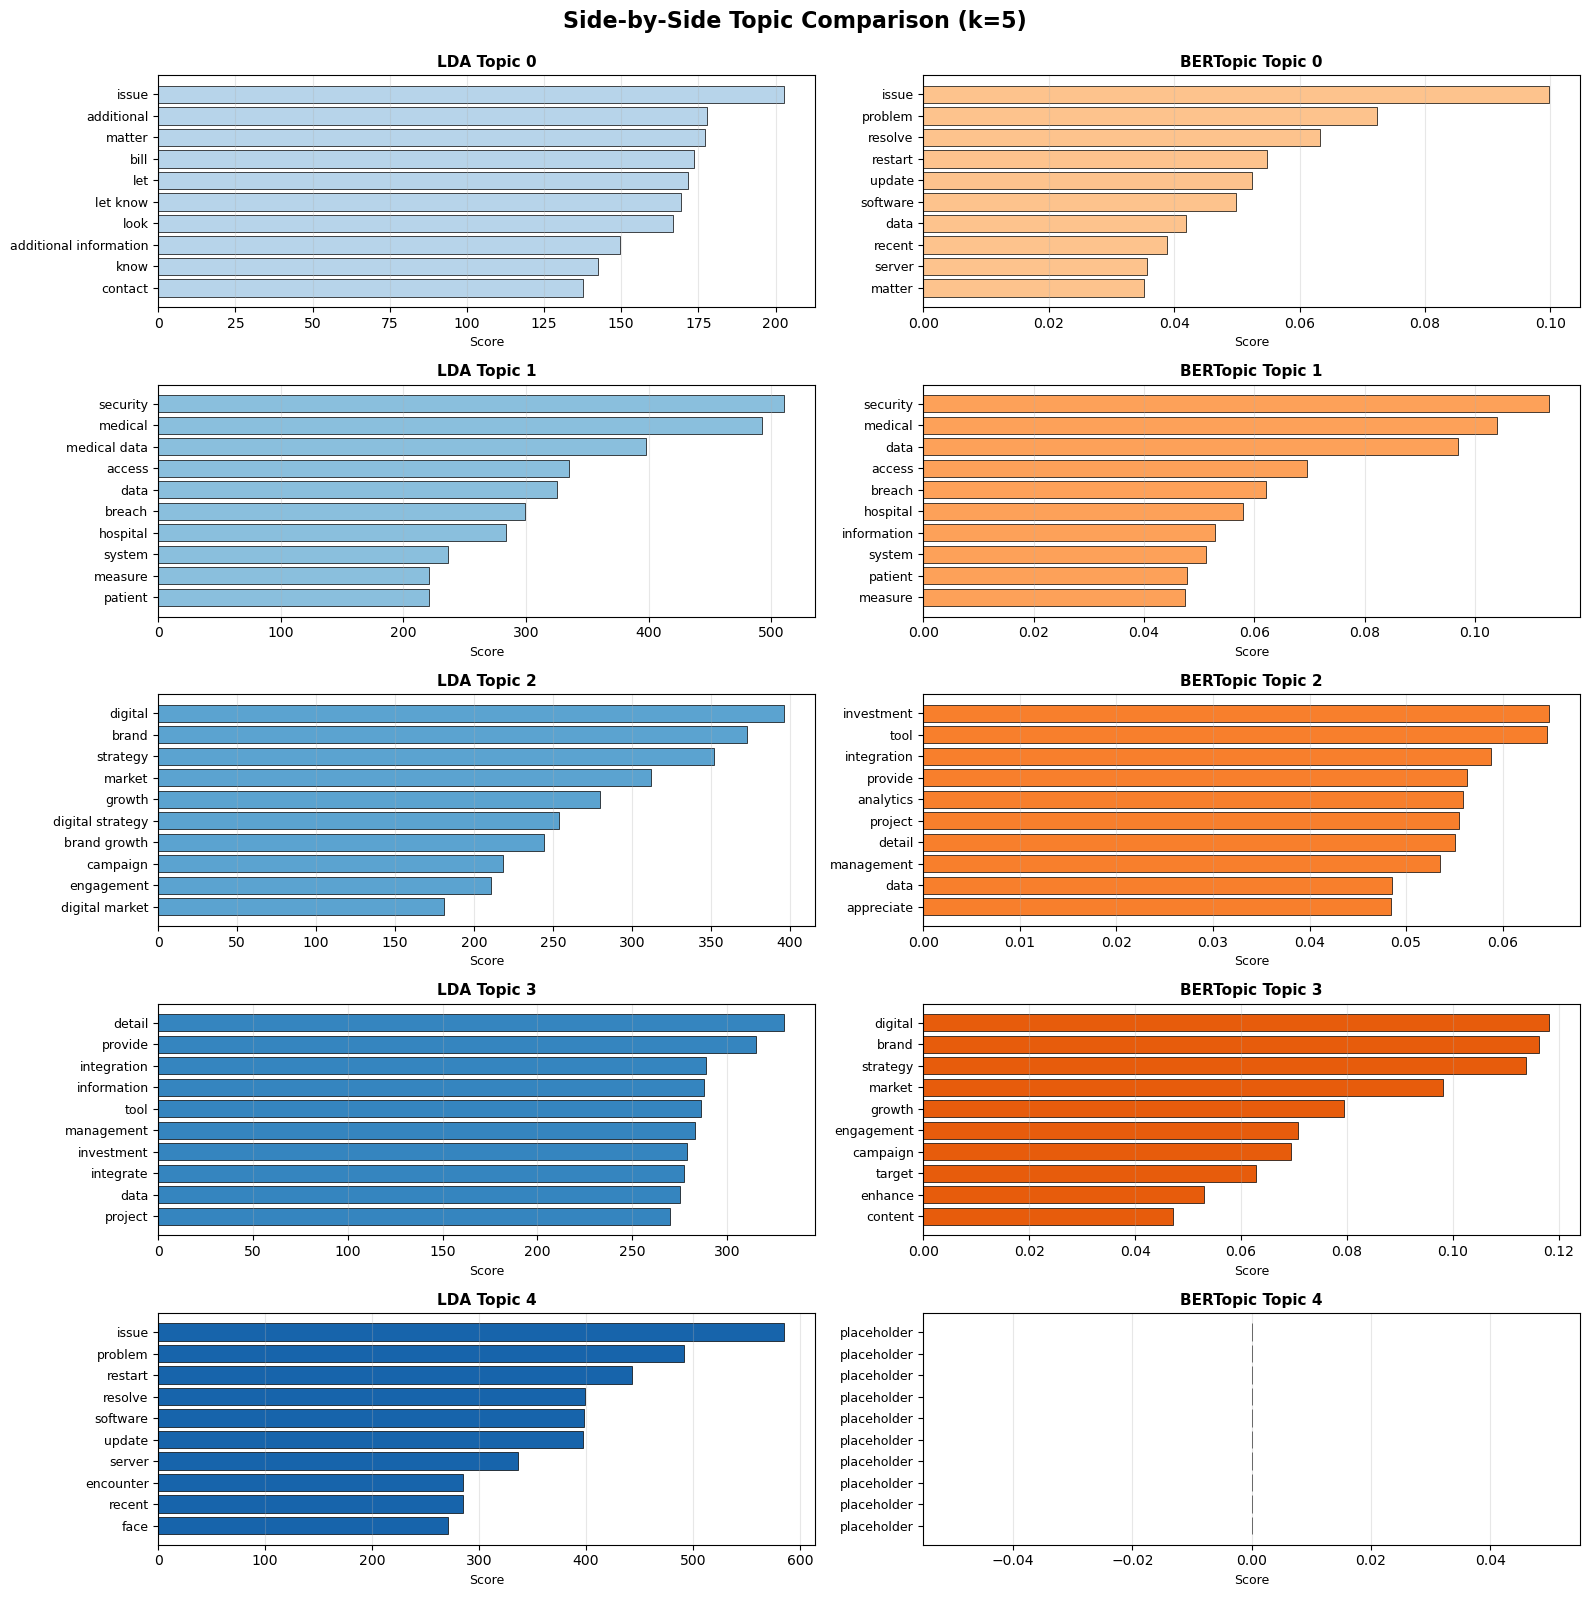

In [19]:
# 3. Side-by-Side Topic Words
fig, axes = plt.subplots(5, 2, figsize=(16, 16))

colors_lda = plt.cm.Blues(np.linspace(0.3, 0.8, 5))
colors_bert = plt.cm.Oranges(np.linspace(0.3, 0.8, 5))

for topic_id in range(N_TOPICS):
    # LDA
    ax_lda = axes[topic_id, 0]
    words_lda, scores_lda = zip(*lda_topics_words[topic_id][:10])
    ax_lda.barh(range(10), scores_lda[::-1], color=colors_lda[topic_id], edgecolor='black', linewidth=0.5)
    ax_lda.set_yticks(range(10))
    ax_lda.set_yticklabels(words_lda[::-1], fontsize=9)
    ax_lda.set_xlabel('Score', fontsize=9)
    ax_lda.set_title(f'LDA Topic {topic_id}', fontweight='bold', fontsize=11)
    ax_lda.grid(axis='x', alpha=0.3)
    
    # BERTopic
    ax_bert = axes[topic_id, 1]
    if bert_topics_words[topic_id] and len(bert_topics_words[topic_id]) > 0:
        words_bert, scores_bert = zip(*bert_topics_words[topic_id][:10])
        ax_bert.barh(range(len(words_bert)), scores_bert[::-1], color=colors_bert[topic_id], 
                     edgecolor='black', linewidth=0.5)
        ax_bert.set_yticks(range(len(words_bert)))
        ax_bert.set_yticklabels(words_bert[::-1], fontsize=9)
        ax_bert.set_xlabel('Score', fontsize=9)
    ax_bert.set_title(f'BERTopic Topic {topic_id}', fontweight='bold', fontsize=11)
    ax_bert.grid(axis='x', alpha=0.3)

plt.suptitle('Side-by-Side Topic Comparison (k=5)', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../Outputs/axis2_side_by_side_topics.png')
plt.show()



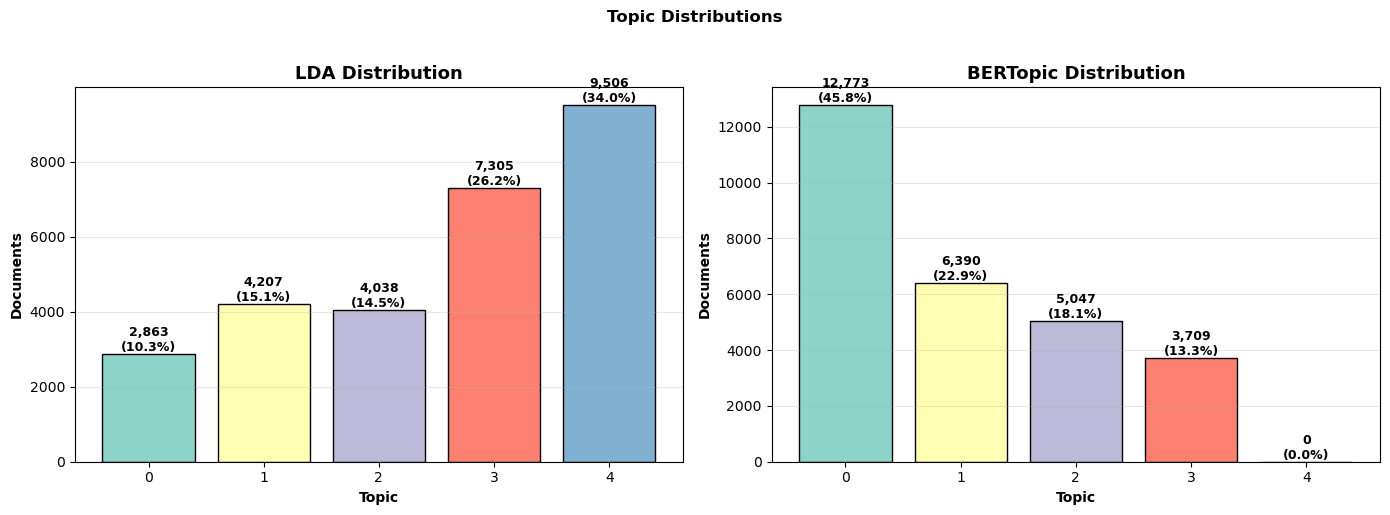

In [20]:
# 4. Topic Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.Set3(range(5))

lda_counts = np.bincount(lda_topics, minlength=N_TOPICS)
axes[0].bar(range(N_TOPICS), lda_counts, color=colors, edgecolor='black', linewidth=1)
axes[0].set_xlabel('Topic', fontweight='bold')
axes[0].set_ylabel('Documents', fontweight='bold')
axes[0].set_title('LDA Distribution', fontweight='bold', fontsize=13)
axes[0].set_xticks(range(N_TOPICS))
axes[0].grid(axis='y', alpha=0.3)

for i, count in enumerate(lda_counts):
    axes[0].text(i, count, f'{count:,}\n({count/len(texts)*100:.1f}%)', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')

bert_counts = np.bincount(bert_topics, minlength=N_TOPICS)
axes[1].bar(range(N_TOPICS), bert_counts, color=colors, edgecolor='black', linewidth=1)
axes[1].set_xlabel('Topic', fontweight='bold')
axes[1].set_ylabel('Documents', fontweight='bold')
axes[1].set_title('BERTopic Distribution', fontweight='bold', fontsize=13)
axes[1].set_xticks(range(N_TOPICS))
axes[1].grid(axis='y', alpha=0.3)

for i, count in enumerate(bert_counts):
    axes[1].text(i, count, f'{count:,}\n({count/len(texts)*100:.1f}%)', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Topic Distributions',fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../Outputs/axis2_distributions.png')
plt.show()



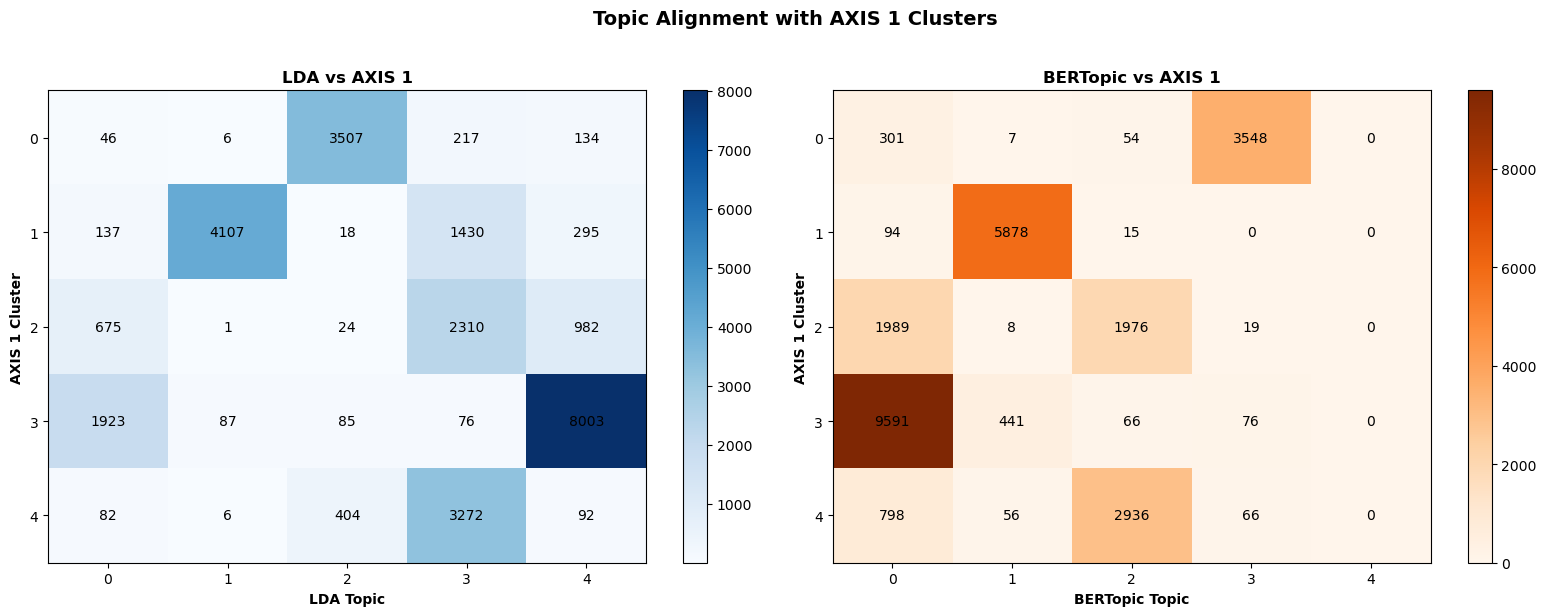

In [21]:
# 5. Confusion Matrices (Topics vs AXIS 1 Clusters)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_lda = confusion_matrix(axis1_clusters, lda_topics)
im1 = axes[0].imshow(cm_lda, cmap='Blues', aspect='auto')
axes[0].set_title('LDA vs AXIS 1', fontsize=12, fontweight='bold')
axes[0].set_xlabel('LDA Topic', fontweight='bold')
axes[0].set_ylabel('AXIS 1 Cluster', fontweight='bold')
axes[0].set_xticks(range(N_TOPICS))
axes[0].set_yticks(range(N_TOPICS))

for i in range(N_TOPICS):
    for j in range(N_TOPICS):
        axes[0].text(j, i, f'{cm_lda[i, j]}', ha="center", va="center", color="black", fontsize=10)

plt.colorbar(im1, ax=axes[0])

cm_bert = confusion_matrix(axis1_clusters, bert_topics)
im2 = axes[1].imshow(cm_bert, cmap='Oranges', aspect='auto')
axes[1].set_title('BERTopic vs AXIS 1', fontsize=12, fontweight='bold')
axes[1].set_xlabel('BERTopic Topic', fontweight='bold')
axes[1].set_ylabel('AXIS 1 Cluster', fontweight='bold')
axes[1].set_xticks(range(N_TOPICS))
axes[1].set_yticks(range(N_TOPICS))

for i in range(N_TOPICS):
    for j in range(N_TOPICS):
        axes[1].text(j, i, f'{cm_bert[i, j]}', ha="center", va="center", color="black", fontsize=10)

plt.colorbar(im2, ax=axes[1])

plt.suptitle('Topic Alignment with AXIS 1 Clusters', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../Outputs/axis2_confusion_matrices.png', dpi=300)
plt.show()


## Summary & Results

In [22]:
# Results table
results_df = pd.DataFrame({
    'Metric': ['Coherence', 'Diversity', 'ARI (vs AXIS 1)', 'NMI (vs AXIS 1)', 'Perplexity'],
    'LDA': [lda_coherence, lda_diversity, lda_ari, lda_nmi, lda.perplexity(X_tfidf)],
    'BERTopic': [bert_coherence, bert_diversity, bert_ari, bert_nmi, np.nan]
})

print("\n" + "="*70)
print("AXIS 2 RESULTS")
print("="*70)
print(results_df.to_string(index=False))

results_df.to_csv('../Outputs/axis2_results.csv', index=False)



AXIS 2 RESULTS
         Metric         LDA  BERTopic
      Coherence    0.779945  0.761727
      Diversity    0.960000  0.780000
ARI (vs AXIS 1)    0.512888  0.630749
NMI (vs AXIS 1)    0.543700  0.650573
     Perplexity 2390.810282       NaN


In [23]:
# Topic comparison table
comparison_data = []

for topic_id in range(N_TOPICS):
    lda_words = [w for w, s in lda_topics_words[topic_id][:10]]
    
    if bert_topics_words[topic_id] and len(bert_topics_words[topic_id]) > 0:
        bert_words = [w for w, s in bert_topics_words[topic_id][:10]]
    else:
        bert_words = ["[empty]"] * 10
    
    comparison_data.append({
        'Topic': topic_id,
        'LDA_Top_Words': ', '.join(lda_words),
        'BERTopic_Top_Words': ', '.join(bert_words)
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*70)
print("TOPIC WORD COMPARISON")
print("="*70)
for _, row in comparison_df.iterrows():
    print(f"\nTopic {row['Topic']}:")
    print(f"  LDA:      {row['LDA_Top_Words']}")
    print(f"  BERTopic: {row['BERTopic_Top_Words']}")

comparison_df.to_csv('../Outputs/axis2_topic_comparison.csv', index=False)



TOPIC WORD COMPARISON

Topic 0:
  LDA:      issue, additional, matter, bill, let, let know, look, additional information, know, contact
  BERTopic: issue, problem, resolve, restart, update, software, data, recent, server, matter

Topic 1:
  LDA:      security, medical, medical data, access, data, breach, hospital, system, measure, patient
  BERTopic: security, medical, data, access, breach, hospital, information, system, patient, measure

Topic 2:
  LDA:      digital, brand, strategy, market, growth, digital strategy, brand growth, campaign, engagement, digital market
  BERTopic: investment, tool, integration, provide, analytics, project, detail, management, data, appreciate

Topic 3:
  LDA:      detail, provide, integration, information, tool, management, investment, integrate, data, project
  BERTopic: digital, brand, strategy, market, growth, engagement, campaign, target, enhance, content

Topic 4:
  LDA:      issue, problem, restart, resolve, software, update, server, encounter, r